In [2]:
import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Libraries imported successfully")

c:\Users\USER\Documents\Python Project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Libraries imported successfully


In [ ]:
path = kagglehub.dataset_download(
    "shivamb/machine-predictive-maintenance-classification"
)

csv_file = [f for f in os.listdir(path) if f.endswith(".csv")][0]
df = pd.read_csv(os.path.join(path, csv_file))

df.to_csv("../data/raw_data.csv", index=False)
print(f"✅ Dataset loaded — {df.shape[0]} rows × {df.shape[1]} columns")
print(f"📁 Saved to data/raw_data.csv")

✅ Dataset loaded — 10000 rows × 10 columns
📁 Saved to data/raw_data.csv


In [4]:
print(f"Shape: {df.shape}")
print(f"\nColumn Names & Types:")
print(df.dtypes)

Shape: (10000, 10)

Column Names & Types:
UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Target                       int64
Failure Type                object
dtype: object


In [5]:
df.head(10)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure
5,6,M14865,M,298.1,308.6,1425,41.9,11,0,No Failure
6,7,L47186,L,298.1,308.6,1558,42.4,14,0,No Failure
7,8,L47187,L,298.1,308.6,1527,40.2,16,0,No Failure
8,9,M14868,M,298.3,308.7,1667,28.6,18,0,No Failure
9,10,M14869,M,298.5,309.0,1741,28.0,21,0,No Failure


In [6]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
Failure Type               0
dtype: int64

In [7]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


In [8]:
failure_count = df["Failure Type"].value_counts()
total = len(df)

print("Machine Failure Distribution:")
print(f"   No Failure (0): {failure_count.iloc[0]} rows ({failure_count.iloc[0]/total*100:.1f}%)")
print(f"   Failure    (1): {failure_count.iloc[1]} rows ({failure_count.iloc[1]/total*100:.1f}%)")

Machine Failure Distribution:
   No Failure (0): 9652 rows (96.5%)
   Failure    (1): 112 rows (1.1%)


In [9]:
print("⚠️ Failure Type Breakdown:")
print(df["Failure Type"].value_counts())

⚠️ Failure Type Breakdown:
Failure Type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: count, dtype: int64


In [10]:
def assign_health_class(row):
    ft = row["Failure Type"]
    if ft == "No Failure":
        return "Normal"
    elif ft == "Power Failure":
        return "Early Warning"
    elif ft == "Heat Dissipation Failure":
        return "Degraded"
    elif ft in ["Overstrain Failure", "Tool Wear Failure"]:
        return "Critical"
    else:
        return "Early Warning"  # Random Failures fallback

df["Health_Class"] = df.apply(assign_health_class, axis=1)

print("🏥 Health Class Distribution:")
health_counts = df["Health_Class"].value_counts()
for label, count in health_counts.items():
    print(f"   {label}: {count} rows ({count/total*100:.2f}%)")

🏥 Health Class Distribution:
   Normal: 9652 rows (96.52%)
   Critical: 123 rows (1.23%)
   Early Warning: 113 rows (1.13%)
   Degraded: 112 rows (1.12%)


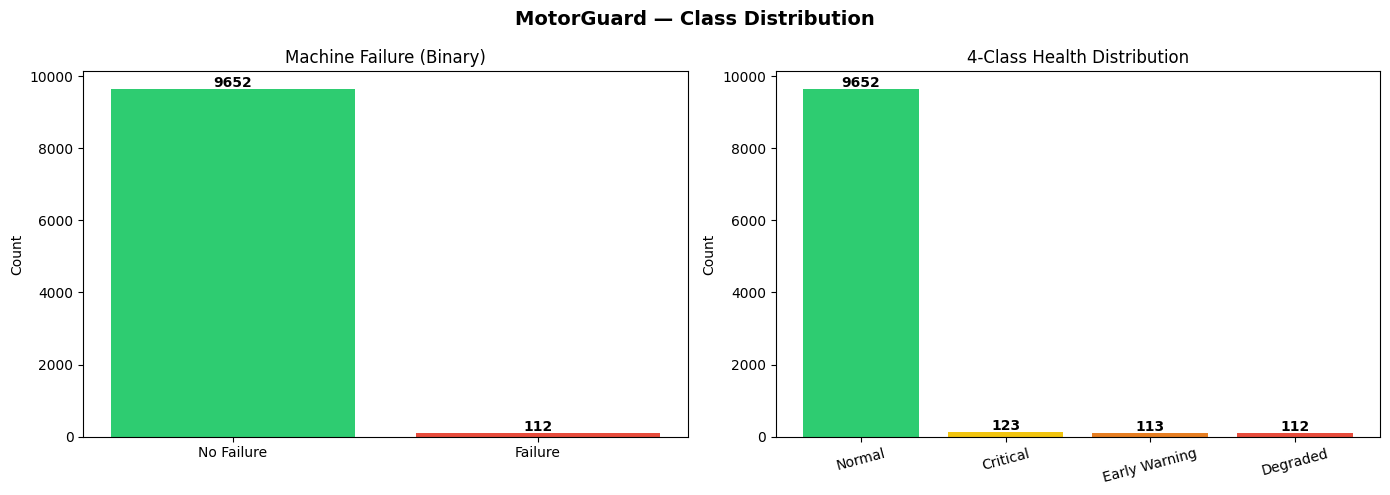

✅ Plot 1 saved


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("MotorGuard — Class Distribution", fontsize=14, fontweight="bold")

# Left: Binary failure
axes[0].bar(["No Failure", "Failure"],
            [failure_count.iloc[0], failure_count.iloc[1]],
            color=["#2ecc71", "#e74c3c"])
axes[0].set_title("Machine Failure (Binary)")
axes[0].set_ylabel("Count")
for i, v in enumerate([failure_count.iloc[0], failure_count.iloc[1]]):
    axes[0].text(i, v + 50, str(v), ha="center", fontweight="bold")

# Right: 4-class health
colors_health = ["#2ecc71", "#f1c40f", "#e67e22", "#e74c3c"]
axes[1].bar(health_counts.index, health_counts.values, color=colors_health)
axes[1].set_title("4-Class Health Distribution")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=15)
for i, v in enumerate(health_counts.values):
    axes[1].text(i, v + 50, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("../notebooks/plot1_class_distribution.png", dpi=150)
plt.show()
print("✅ Plot 1 saved")

In [12]:
# Power in Watts
df["Power_W"] = (2 * np.pi * df["Rotational speed [rpm]"] * df["Torque [Nm]"]) / 60

# Temperature gap — should always be ~10K
df["Temp_Delta"] = df["Process temperature [K]"] - df["Air temperature [K]"]

# Overstrain proxy
df["Wear_Torque"] = df["Tool wear [min]"] * df["Torque [Nm]"]

print("⚙️  Engineered Features Added:")
print(f"   Power_W     — Mean: {df['Power_W'].mean():.1f} W")
print(f"   Temp_Delta  — Mean: {df['Temp_Delta'].mean():.2f} K")
print(f"   Wear_Torque — Mean: {df['Wear_Torque'].mean():.1f}")

⚙️  Engineered Features Added:
   Power_W     — Mean: 6279.7 W
   Temp_Delta  — Mean: 10.00 K
   Wear_Torque — Mean: 4314.7


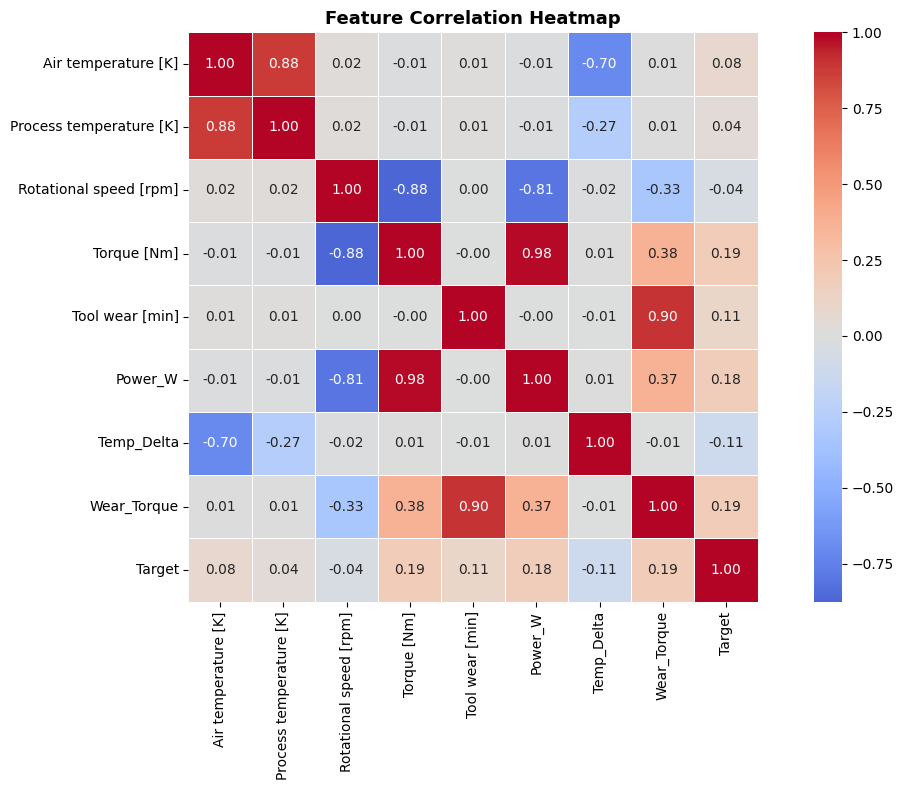

✅ Plot 2 saved


In [13]:
# Only numeric columns for correlation
feature_cols = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Power_W",
    "Temp_Delta",
    "Wear_Torque",
    "Target"              # numeric 0/1 column
]

plt.figure(figsize=(12, 8))
corr = df[feature_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f",
            cmap="coolwarm", center=0,
            square=True, linewidths=0.5)
plt.title("Feature Correlation Heatmap", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../notebooks/plot2_correlation_heatmap.png", dpi=150)
plt.show()
print("✅ Plot 2 saved")

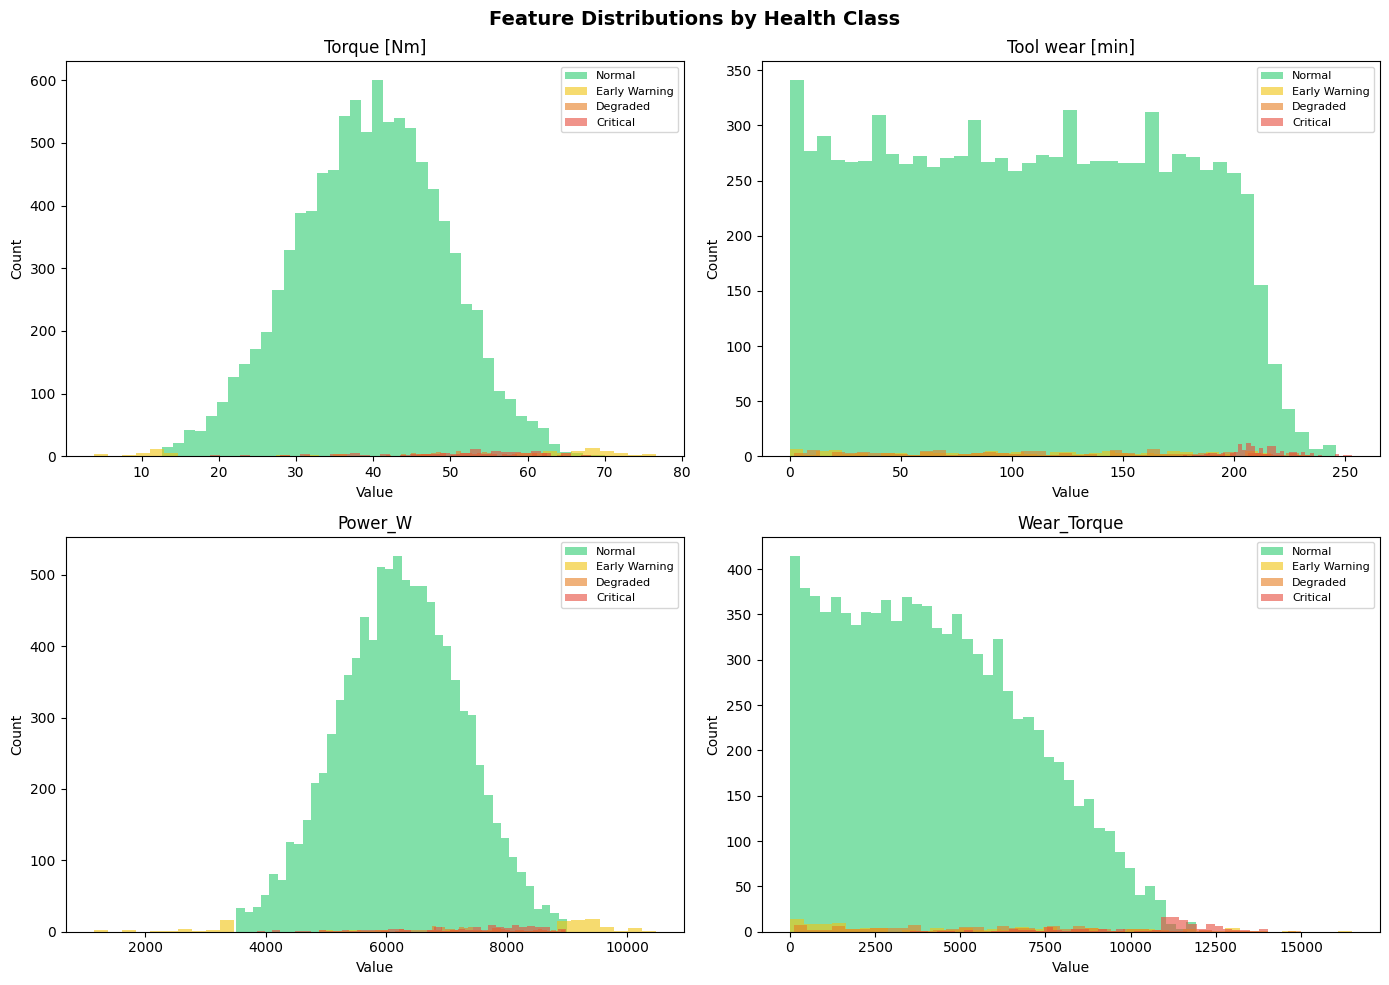

✅ Plot 3 saved


In [14]:
plot_features = ["Torque [Nm]", "Tool wear [min]", "Power_W", "Wear_Torque"]

health_colors = {
    "Normal":        "#2ecc71",
    "Early Warning": "#f1c40f",
    "Degraded":      "#e67e22",
    "Critical":      "#e74c3c"
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Feature Distributions by Health Class",
             fontsize=14, fontweight="bold")
axes = axes.flatten()

for i, feature in enumerate(plot_features):
    for health_class, color in health_colors.items():
        subset = df[df["Health_Class"] == health_class][feature]
        axes[i].hist(subset, bins=40, alpha=0.6,
                     label=health_class, color=color)
    axes[i].set_title(feature)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Count")
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.savefig("../notebooks/plot3_feature_distributions.png", dpi=150)
plt.show()
print("✅ Plot 3 saved")

In [32]:
df.to_csv("../data/processed_data.csv", index=False)


print(" EDA SUMMARY")

print(f"   Total rows         : {total:,}")
print(f"   Total columns      : {df.shape[1]}")
print(f"   Missing values     : None")
print(f"   Failure rate       : {failure_count[1]/total*100:.1f}%")
print(f"   Health classes     : {df['Health_Class'].nunique()}")
print(f"   Engineered feats   : Power_W, Temp_Delta, Wear_Torque")
print(f"   Plots saved        : 3")
print(f"   Processed data     : data/processed_data.csv")



 EDA SUMMARY
   Total rows         : 10,000
   Total columns      : 15
   Missing values     : None
   Failure rate       : 1.1%
   Health classes     : 4
   Engineered feats   : Power_W, Temp_Delta, Wear_Torque
   Plots saved        : 3
   Processed data     : data/processed_data.csv


C:\Users\USER\AppData\Local\Temp\ipykernel_11172\1987711207.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"   Failure rate       : {failure_count[1]/total*100:.1f}%")


In [16]:
print(df.columns.tolist())
print(df["Failure Type"].value_counts())

['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Target', 'Failure Type', 'Health_Class', 'Power_W', 'Temp_Delta', 'Wear_Torque']
Failure Type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: count, dtype: int64


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import joblib
import os

print("✅ Libraries imported")

✅ Libraries imported


In [18]:
df = pd.read_csv("../data/processed_data.csv")

print(f"✅ Data loaded — {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumns available:")
print(df.columns.tolist())

✅ Data loaded — 10000 rows × 14 columns

Columns available:
['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Target', 'Failure Type', 'Health_Class', 'Power_W', 'Temp_Delta', 'Wear_Torque']


In [19]:
# Type column contains L, M, H (Low, Medium, High quality)
# The model needs numbers not letters

print("Before encoding:")
print(df["Type"].value_counts())

le = LabelEncoder()
df["Type_encoded"] = le.fit_transform(df["Type"])

print("\nAfter encoding:")
print(df[["Type", "Type_encoded"]].drop_duplicates().sort_values("Type_encoded"))
print("\nMapping:")
for i, label in enumerate(le.classes_):
    print(f"   {label} → {i}")

Before encoding:
Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

After encoding:
   Type  Type_encoded
10    H             0
1     L             1
0     M             2

Mapping:
   H → 0
   L → 1
   M → 2


In [20]:
# These columns must be dropped before modelling:
# - "Failure Type"  → text version of what we already encoded into Health_Class
# - "Target"        → numeric version of same thing
# - "UDI"           → just a row ID number, meaningless to the model
# - "Product ID"    → just a product identifier, not a sensor reading
# - "Type"          → replaced by Type_encoded

columns_to_drop = [
    "UDI",
    "Product ID",
    "Type",
    "Target",
    "Failure Type"
]

# Only drop columns that actually exist
columns_to_drop = [c for c in columns_to_drop if c in df.columns]
df_clean = df.drop(columns=columns_to_drop)

print("✅ Leakage columns dropped")
print(f"\nRemaining columns ({len(df_clean.columns)}):")
print(df_clean.columns.tolist())

✅ Leakage columns dropped

Remaining columns (10):
['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Health_Class', 'Power_W', 'Temp_Delta', 'Wear_Torque', 'Type_encoded']


In [21]:
# Everything except Health_Class is a feature
# Health_Class is what the model will predict

feature_cols = [c for c in df_clean.columns if c != "Health_Class"]
X = df_clean[feature_cols]
y = df_clean["Health_Class"]

print(f"✅ Features (X): {X.shape[1]} columns")
print(f"   {feature_cols}")
print(f"\n✅ Target (y): Health_Class")
print(f"\nClass distribution:")
print(y.value_counts())

✅ Features (X): 9 columns
   ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Power_W', 'Temp_Delta', 'Wear_Torque', 'Type_encoded']

✅ Target (y): Health_Class

Class distribution:
Health_Class
Normal           9652
Critical          123
Early Warning     113
Degraded          112
Name: count, dtype: int64


In [22]:
# 80% training, 20% testing
# stratify=y ensures both splits have same class proportions

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"✅ Split complete")
print(f"\n   Training set   : {X_train.shape[0]} rows")
print(f"   Test set       : {X_test.shape[0]} rows")
print(f"\nTraining class distribution:")
print(y_train.value_counts())
print(f"\nTest class distribution:")
print(y_test.value_counts())

✅ Split complete

   Training set   : 8000 rows
   Test set       : 2000 rows

Training class distribution:
Health_Class
Normal           7722
Critical           98
Degraded           90
Early Warning      90
Name: count, dtype: int64

Test class distribution:
Health_Class
Normal           1930
Critical           25
Early Warning      23
Degraded           22
Name: count, dtype: int64


In [23]:
# SMOTE creates synthetic examples of minority classes
# CRITICAL: Applied on TRAINING SET ONLY
# Never touch the test set — it must stay real

print("Before SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE:")
balanced_counts = pd.Series(y_train_balanced).value_counts()
print(balanced_counts)
print(f"\nTraining set grew from {len(y_train)} → {len(y_train_balanced)} rows")

Before SMOTE:
Health_Class
Normal           7722
Critical           98
Degraded           90
Early Warning      90
Name: count, dtype: int64

After SMOTE:
Health_Class
Normal           7722
Degraded         7722
Critical         7722
Early Warning    7722
Name: count, dtype: int64

Training set grew from 8000 → 30888 rows


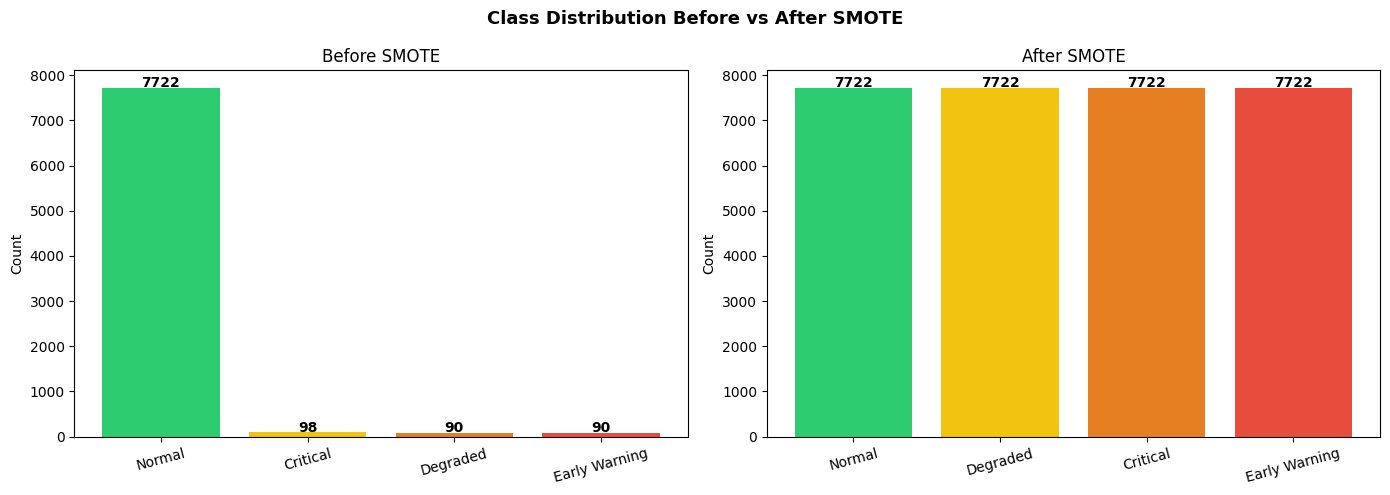

✅ Plot 4 saved — notebooks/plot4_smote_effect.png


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Class Distribution Before vs After SMOTE",
             fontsize=13, fontweight="bold")

colors = ["#2ecc71", "#f1c40f", "#e67e22", "#e74c3c"]

# Before
before_counts = y_train.value_counts()
axes[0].bar(before_counts.index, before_counts.values, color=colors)
axes[0].set_title("Before SMOTE")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=15)
for i, v in enumerate(before_counts.values):
    axes[0].text(i, v + 10, str(v), ha="center", fontweight="bold")

# After
axes[1].bar(balanced_counts.index, balanced_counts.values, color=colors)
axes[1].set_title("After SMOTE")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=15)
for i, v in enumerate(balanced_counts.values):
    axes[1].text(i, v + 10, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("../notebooks/plot4_smote_effect.png", dpi=150)
plt.show()
print("✅ Plot 4 saved — notebooks/plot4_smote_effect.png")

In [25]:
# StandardScaler brings all features to same scale
# Mean = 0, Standard Deviation = 1
# Critical rule: fit on training data ONLY, transform both

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled  = scaler.transform(X_test)  # NO fit here — transform only

print("✅ Features scaled")
print(f"\n   Training set shape : {X_train_scaled.shape}")
print(f"   Test set shape     : {X_test_scaled.shape}")
print(f"\nFeature means after scaling (should all be ~0):")
means = X_train_scaled.mean(axis=0).round(4)
for col, mean in zip(feature_cols, means):
    print(f"   {col}: {mean}")

✅ Features scaled

   Training set shape : (30888, 9)
   Test set shape     : (2000, 9)

Feature means after scaling (should all be ~0):
   Air temperature [K]: -0.0
   Process temperature [K]: 0.0
   Rotational speed [rpm]: -0.0
   Torque [Nm]: -0.0
   Tool wear [min]: 0.0
   Power_W: 0.0
   Temp_Delta: 0.0
   Wear_Torque: 0.0
   Type_encoded: -0.0


In [26]:
os.makedirs("../artifacts", exist_ok=True)

# Save scaler
joblib.dump(scaler, "../artifacts/scaler.pkl")

# Save train and test sets
np.save("../artifacts/X_train_scaled.npy", X_train_scaled)
np.save("../artifacts/X_test_scaled.npy",  X_test_scaled)
np.save("../artifacts/y_train.npy",         y_train_balanced)
np.save("../artifacts/y_test.npy",           y_test)

# Save feature column names for use in API later
joblib.dump(feature_cols, "../artifacts/feature_cols.pkl")

print("✅ All artifacts saved to artifacts/ folder:")
print("   - scaler.pkl")
print("   - X_train_scaled.npy")
print("   - X_test_scaled.npy")
print("   - y_train.npy")
print("   - y_test.npy")
print("   - feature_cols.pkl")

✅ All artifacts saved to artifacts/ folder:
   - scaler.pkl
   - X_train_scaled.npy
   - X_test_scaled.npy
   - y_train.npy
   - y_test.npy
   - feature_cols.pkl


In [30]:

print("PREPROCESSING SUMMARY")

print(f"   Original rows        : 10,000")
print(f"   Features used        : {len(feature_cols)}")
print(f"   Feature list         : {feature_cols}")
print(f"   Training rows        : {X_train_scaled.shape[0]} (after SMOTE)")
print(f"   Test rows            : {X_test_scaled.shape[0]} (untouched)")
print(f"   Scaler               : StandardScaler saved ✅")
print(f"   Leakage columns      : Dropped ✅")
print(f"   Class balance        : Fixed with SMOTE ✅")



PREPROCESSING SUMMARY
   Original rows        : 10,000
   Features used        : 9
   Feature list         : ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Power_W', 'Temp_Delta', 'Wear_Torque', 'Type_encoded']
   Training rows        : 30888 (after SMOTE)
   Test rows            : 2000 (untouched)
   Scaler               : StandardScaler saved ✅
   Leakage columns      : Dropped ✅
   Class balance        : Fixed with SMOTE ✅
